In [1]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [2]:
# Paramètres audio
SR           = 22050      # Sample rate cible (Hz)
TARGET_LEN   = SR * 6     # Durée fixe : 6 secondes = 132 300 samples
MIN_DURATION = 4.0        # Drop fichiers < 4 secondes

# Filtrage bandpass 
BANDPASS_LOW  = 100       # Hz — coupe bruits mécaniques (stéthoscope, mouvements)
BANDPASS_HIGH = 2000      # Hz — coupe bruits parasites hautes fréquences

# Spectrogramme Mel 
N_MELS     = 224          # Valeur de base 128
N_FFT      = 2048
HOP_LENGTH = 590          # Valeur de base 512

# Features acoustiques 
N_MFCC = 13

# Sorties 
PROCESSED_DIR = '../data/processed'

In [3]:
# Filtrage bandpass 
def bandpass_filter(audio, lowcut=BANDPASS_LOW, highcut=BANDPASS_HIGH, sr=SR, order=4):
    """Filtre passe-bande : conserve uniquement 100–2000 Hz."""
    nyquist = sr / 2
    b, a = butter(order, [lowcut / nyquist, highcut / nyquist], btype='band')
    return filtfilt(b, a, audio).astype(np.float32)


# Pad centré / crop 
def pad_or_crop(audio, target_len=TARGET_LEN):
    """Pad avec silence centré ou crop pour atteindre exactement target_len samples."""
    if len(audio) < target_len:
        pad_total = target_len - len(audio)
        pad_left = pad_total // 2
        audio = np.pad(audio, (pad_left, pad_total - pad_left))
    else:
        audio = audio[:target_len]
    return audio


# Pipeline complet de prétraitement
def preprocess_audio(audio, sr=SR, target_len=TARGET_LEN):
    """Pipeline : Trim silences, Filtre passe-bande, Normalisation amplitude, Pad centré. """
    audio, _ = librosa.effects.trim(audio, top_db=20)
    audio = bandpass_filter(audio)
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    audio = pad_or_crop(audio, target_len)
    return audio

# Spectrogramme Mel
def compute_mel_spectrogram(audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    return librosa.power_to_db(mel, ref=np.max)

## Q5. Standardisation audio : sample rate, durée, padding/crop

## Q8. Débruitage : filtre passe-bande 100 - 2000 Hz + trim silences

In [4]:
def load_and_preprocess(data_dir='../data'):
    """
    Charge + prétraite les fichiers WAV :
    - Drop fichiers < MIN_DURATION
    - Resample à SR via librosa.load
    - Pipeline complet : trim → bandpass 100-2000 Hz → normalise → pad/crop
    """
    x_proc, y = [], []
    dropped = 0

    for label in sorted(os.listdir(data_dir)):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for file in sorted(os.listdir(label_dir)):
            if not file.lower().endswith('.wav'):
                continue
            path = os.path.join(label_dir, file)
            if librosa.get_duration(path=path) < MIN_DURATION:
                print(f"  Dropped : {file}")
                dropped += 1
                continue
            audio, _ = librosa.load(path, sr=SR)
            x_proc.append(preprocess_audio(audio))
            y.append(label.lower())

    print(f"\nChargé : {len(x_proc)} fichiers | Droppés : {dropped}")
    print(f"Shape  : ({len(x_proc)}, {TARGET_LEN}) — {TARGET_LEN/SR:.0f}s à {SR}Hz")
    return np.stack(x_proc), np.array(y)


X, y = load_and_preprocess('../data')

c:\Users\lrozier\Documents\UQAC\respiratory-disease-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Dropped : P5BronchialTc_25.wav
  Dropped : P8BronchialSc_38.wav
  Dropped : P9BronchialTc_45.wav
  Dropped : P10AsthmaIE_49.wav
  Dropped : P20WheezingIE_97.wav
  Dropped : P22WheezingRL_107.wav
  Dropped : P2AsthmaIU_6.wav
  Dropped : P43WheezingRL_215.wav
  Dropped : P44WheezingIU_218.wav
  Dropped : P38Pneumonia35P.wav

Chargé : 1201 fichiers | Droppés : 10
Shape  : (1201, 132300) — 6s à 22050Hz


In [5]:
labels_unique = sorted(np.unique(y))

shapes = set(a.shape for a in X)
print(f"Shapes uniques : {shapes}")
print(f"Toutes identiques : {len(shapes) == 1}")
print(f"\nClasses : {labels_unique}")
print(f"Distribution : { {c: int((y == c).sum()) for c in labels_unique} }")

Shapes uniques : {(132300,)}
Toutes identiques : True

Classes : [np.str_('asthma'), np.str_('bronchial'), np.str_('copd'), np.str_('healthy'), np.str_('pneumonia')]
Distribution : {np.str_('asthma'): 282, np.str_('bronchial'): 101, np.str_('copd'): 401, np.str_('healthy'): 133, np.str_('pneumonia'): 284}


## Q6. Spectrogramme Mel

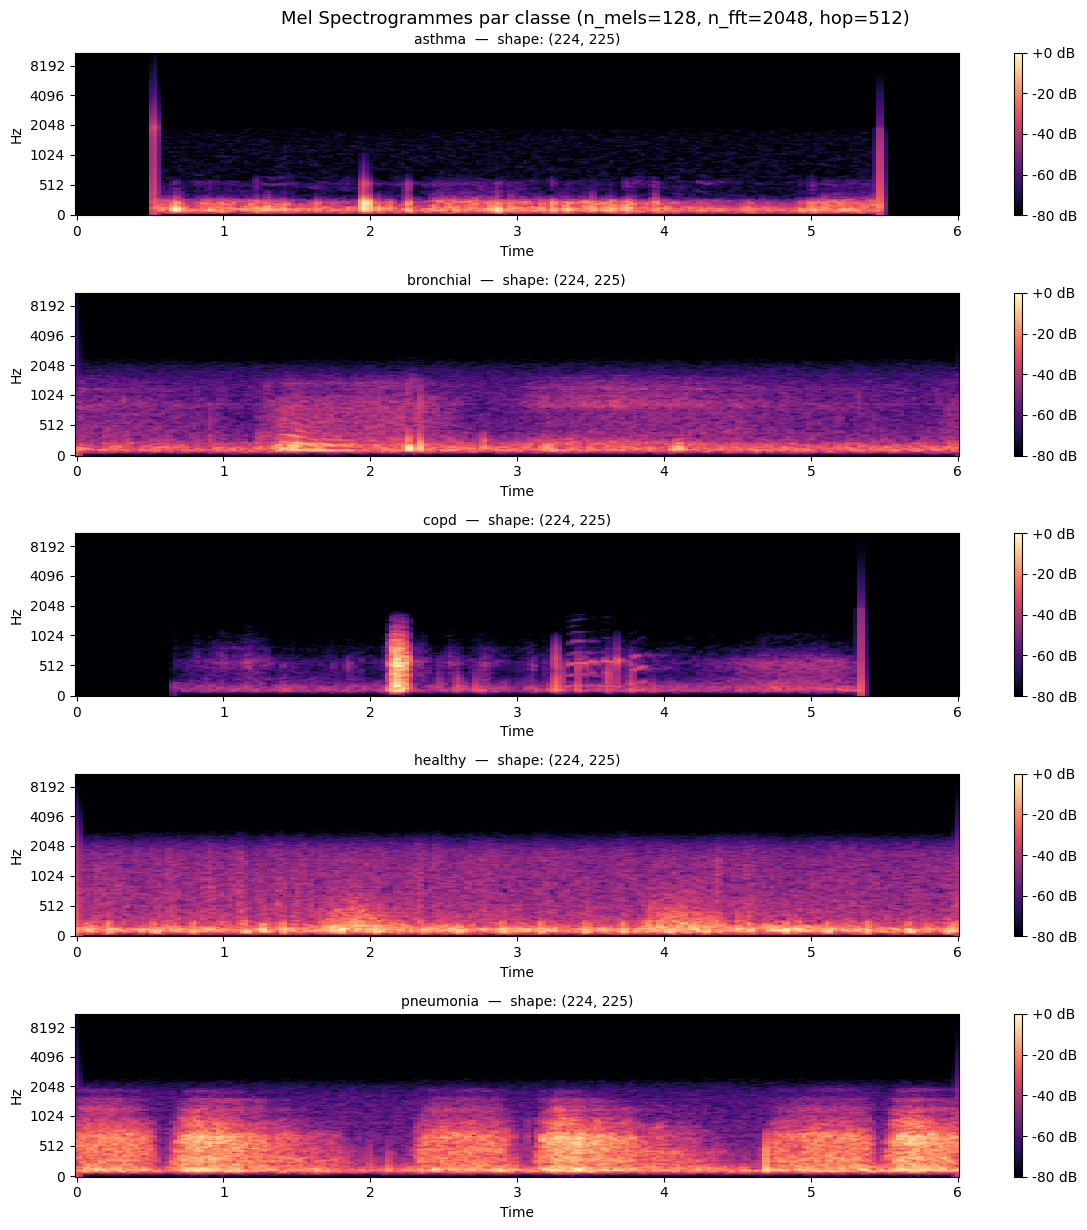

In [6]:
fig, axes = plt.subplots(len(labels_unique), 1, figsize=(12, len(labels_unique) * 2.5))
fig.suptitle('Mel Spectrogrammes par classe (n_mels=128, n_fft=2048, hop=512)', fontsize=13)

for i, label in enumerate(labels_unique):
    idx    = np.where(y == label)[0][0]
    mel_db = compute_mel_spectrogram(X[idx])
    img = librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel',
        ax=axes[i], cmap='magma'
    )
    axes[i].set_title(f'{label}  —  shape: {mel_db.shape}', fontsize=10)
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [7]:
print("Calcul des Mel spectrogrammes")
X_mel = np.array([compute_mel_spectrogram(audio) for audio in X])
print(f"Shape finale : {X_mel.shape} : (n_samples, n_mels, time_frames)")
print(f"Mémoire : {X_mel.nbytes / 1e6:.1f} MB")

Calcul des Mel spectrogrammes
Shape finale : (1201, 224, 225) : (n_samples, n_mels, time_frames)
Mémoire : 242.1 MB


## Q7. Extraction des features acoustiques (MFCC, Centroid, Bandwidth, ZCR)

In [8]:
# Features acoustiques
def extract_features(audio, sr=SR):
    """Vecteur 16 features : 13 MFCC + centroid + bandwidth + ZCR."""
    mfcc      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC).mean(axis=1)
    centroid  = librosa.feature.spectral_centroid(y=audio, sr=sr).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr).mean()
    zcr       = librosa.feature.zero_crossing_rate(audio).mean()
    return np.concatenate([mfcc, [centroid, bandwidth, zcr]])

In [9]:
print("Extraction des features acoustiques...")
X_features = np.array([extract_features(audio) for audio in X])
print(f"Shape : {X_features.shape} : {N_MFCC} MFCC + centroid + bandwidth + ZCR = {X_features.shape[1]} features")

Extraction des features acoustiques...
Shape : (1201, 16) : 13 MFCC + centroid + bandwidth + ZCR = 16 features


In [12]:
os.makedirs(PROCESSED_DIR, exist_ok=True)

np.save(os.path.join(PROCESSED_DIR, 'X.npy'),           X)  # Audio prétraité (raw waveforms)
np.save(os.path.join(PROCESSED_DIR, 'X_mel.npy'),      X_mel)
np.save(os.path.join(PROCESSED_DIR, 'X_features.npy'), X_features)
np.save(os.path.join(PROCESSED_DIR, 'y.npy'),           y)

print(f"Sauvegardé dans {PROCESSED_DIR}/")
print(f"  X.npy          : {X.shape}            — audio prétraité (raw waveforms)")
print(f"  X_mel.npy      : {X_mel.shape}       — Mel spectrogrammes (input CNN/BiLSTM)")
print(f"  X_features.npy : {X_features.shape}  — features acoustiques (input ML baseline)")
print(f"  y.npy          : {y.shape}            — labels classes")

Sauvegardé dans ../data/processed/
  X.npy          : (1201, 132300)            — audio prétraité (raw waveforms)
  X_mel.npy      : (1201, 224, 225)       — Mel spectrogrammes (input CNN/BiLSTM)
  X_features.npy : (1201, 16)  — features acoustiques (input ML baseline)
  y.npy          : (1201,)            — labels classes
